# Implementación de Bandidos de K-brazos #

En este ejercicio estableceremos las tres implementaciones de bandidos de K-brazos. Estos son:
1. Bandido greedy
2. Bandido con &epsilon;-decay
3. Bandido con reocmpensas no estacionarias

Por defecto, utilizaremos bandidos con 10 brazos, sin embargo este será un valor parametrizable.

## 1. Bandido greedy ##

La definición de los bandidos consiste en crear un agente, como una clase de Python, `Bandit`. Inicialmente crearemos un bandido con una cantidad de brazos dado por parámetro (por defecto utilizaremos 10 brazos). 
Cada uno de los brazos del bandido (definidos en una lista `arms` como un atributo de la clase) tiene su propia recompensa, la cual asignaremos como un número flotante aleatorio en el rango `[-3,3]` (utilizando la función `random.uniform(-3,3)` de la librería random). Adicionalmente, definimos un atributo de la clase (`reward`) para mantener la recompensa cumulativa del bandido.
Inicialmente nuestro bandido tiene dos funciones `choose_arm` y `run`.

- `choose_arm` no tienen parámetros. Esta función se encarga de seleccionar un brazo a ejecutar (de forma aleatoria en caso de empate), y retorna la recompensa recibida de acuerdo a la fórmula:

![title](img/bandit_formula.png)

Retornando la recompensa promedio obtenida por el agente al escoger el brazo dado.

Para poder realizar este cálculo, debemos llevar la cuenta de la cantidad de veces que ha sido escogido cada brazo y la recompensa acumulada de cada brazo. Esta información la definimos como atributos de la clase, en las variables `occurrences` y `cumulative_rewards`,  respectivamente. Ambos atributos se definen como una lista de tamaño número de brazos del bandido inicialmente en 0.

El cálculo de la recompensa primero actualiza las ocurrencias de escoger el brazo seleccionado aleatoriamente, `arm`. Además debemos actualizar la recompensa cumulativa del brazo `arm`, sumando la recompensa correspondiente al brazo (obtenida de la lista de brazos). Finalmente, calculamos Q<sub>t</sub>(a) como la recompensa cumulativa sobre las ocurrencias para el brazo dado y retornamos dicho valor. La recompensa global del agente se actualiza con el valor calculado.

- `run` no recibe ningún parámetro. Esta función define la cantidad de episodios para los cuales vamos a calcular la recompensa del agente (1000 en nuestro caso)
Luego creamos un bandido (`bandit`) y una variable para almacenar la recompensa obtenida en cada iteración (`expected_reward`).
Para cada uno de los episodios, ejecutamos el bandido llamando la función choose_arm y guardamos el resultado en la lista de recompensas esperadas.
Finalmente retornamos la lista de recompensas para cada iteración (`expected_reward`).

In [81]:
import random

class Bandit:
    def __init__(self, arms=10, arms_values=None, episodes=10):
        if arms_values is None:
            arms_values = [random.uniform(-3,3) for _ in range(arms)]
        self.arms = arms_values
        self.occurrences = [0 for _ in range(arms)]
        self.cumulative_rewards = [0 for _ in range(arms)]
        
        self.reward = 0
        
        self.episodes = episodes

    def choose_arm(self):
        
        arm = random.choice([idx for idx,i in enumerate(self.cumulative_rewards) if i==max(self.cumulative_rewards)])
        self.occurrences[arm] += 1
        self.cumulative_rewards[arm] += self.arms[arm]
        
        qt = self.cumulative_rewards[arm] / self.occurrences[arm]
        
        self.reward += qt
        return qt

            
    def run(self):
        episodes = self.episodes
        expected_reward = [0 for _i in range(episodes)]
        for i in range(0, episodes):
            expected_reward[i] = self.choose_arm()
        return expected_reward

## 2. Bandidos con &epsilon;-decay ##

Implemente el algoritmos de los bandidos ahora utilizando la estrategia de epsilon decay para mediar entre la exploración y la explotación de los bandidos. **Debe ser una nueva definición completa del bandido**.
Recuerde que esta nueva estrategia se basa en escoger la acción con mayor recompensa esperada Q<sub>n+1</sub> con probabilidad &epsilon; y una acción aleatoria con probabilidad 1-&epsilon;.

Para ello, tome la implementación del bandido realizada en el punto anterior (`Bandit`) y agregando un nuevo atributo `epsilon` con un valor de 0.1 por defecto a la cración del bandido. Además agregue una nueva función `choose_arm` que retorna la acción a tomar, siguiendo las especificaciones del valor &epsilon;. La función `choose_arm` será utilizada desde la función `run` para escoger el brazo.

Finalmente, dentro de la función §run§ asegurese que el valor de &epsilon; decae cada `N` iteraciones (`N` también debe ser un parámetro de la clase `Bandit`)

In [82]:
import random

class Bandit2:
    def __init__(self, arms=10, epsilon=0.1, N=100, arms_values=None,episodes=10):
        # Recompensa real de cada brazo
        if arms_values is None:
            arms_values = [random.uniform(-3, 3) for _ in range(arms)]
        self.arms = arms_values

        # Estadísticas por brazo
        self.occurrences = [0 for _ in range(arms)]
        self.cumulative_rewards = [0 for _ in range(arms)]

        # Recompensa global
        self.reward = 0
        
        self.episodes=episodes

        # Parámetros epsilon-greedy
        self.epsilon = epsilon
        self.N = N

    def choose_arm(self):
        # Decidir explorar o explotar
        if random.random() < self.epsilon:
            # Explotar: elegir brazo con mayor Q
            q_values = [
                self.cumulative_rewards[i] / self.occurrences[i]
                if self.occurrences[i] > 0 else 0
                for i in range(len(self.arms))
            ]

            max_q = max(q_values)
            candidates = [i for i, q in enumerate(q_values) if q == max_q]
            arm = random.choice(candidates)
        else:
            # Explorar: elegir brazo aleatorio
            arm = random.randint(0, len(self.arms) - 1)

        # Actualizar estadísticas
        self.occurrences[arm] += 1
        self.cumulative_rewards[arm] += self.arms[arm]

        # Calcular Q_t(a)
        qt = self.cumulative_rewards[arm] / self.occurrences[arm]

        # Actualizar recompensa global
        self.reward += qt

        return qt

    def run(self):
        episodes = self.episodes
        expected_reward = [0 for _ in range(episodes)]

        for i in range(episodes):
            expected_reward[i] = self.choose_arm()

            # Decaimiento de epsilon cada N episodios
            if (i + 1) % self.N == 0:
                self.epsilon *= 0.9  # decay multiplicativo
                self.epsilon = max(self.epsilon, 0.01)  # evitar que llegue a 0

        return expected_reward


# 3. Bandido con recompensas no estacionarias #

Ahora retomaremos el bandido del punto 2. para permitir que las recompensas sean no estacionarias.
Para lograr este objetivo, debemos realizar las siguientes modificaciones sobre el bandido.
1. Agregar un atributo con los valores iniciales de recompensa para cada brazo. Con este proposito podemos utilizar la el atributo `arms`, que tenia la recompensa de cada brazo.
Por defecto le daremos un valor inicial a cada brazo, como un entero aleatorio entre 1 y el número de brazos.
2. Debemos introducir un atrobuto &alpha; para el bandido que tendra como valor por defecto `0.1`
3. Dentro de la función `expected_reward`, debemos modificar la recompensa de cada episodio para cada brazo. Para ello utilizaremos una función sinusoidal que nos da la recompensa actual como el seno de la multiplicación del paso actual con el brazo. Todo esto como un factor de la recompensa inicial del brazo.
4. Finalmente, dentro de la función `expected_reward`, debemos realizar el cálculo de la recompensa esperada según la fórmula de las recompensas no estacionarias y almacenarla en el atributo `cumulative_rewards` para cada brazo. 


In [83]:
import random
import math

class Bandit3:
    def __init__(self, arms=10, epsilon=0.1, N=100, alpha=0.1,episodes=10):
        self.n_arms = arms

        # Recompensas iniciales (factor base)
        self.arms = [random.randint(1, arms) for _ in range(arms)]
        # print("Arms rewards:", self.arms)
        # print("alternative arms:", [random.randint(1, arms) for _ in range(arms)])
        

        # Q estimados
        self.cumulative_rewards = [0.0 for _ in range(arms)]
        self.occurrences = [0 for _ in range(arms)]

        # Parámetros
        self.epsilon = epsilon
        self.N = N
        self.alpha = alpha

        self.episodes=episodes
        self.reward = 0
        self.step = 0

    def expected_reward(self, arm):
        """
        Recompensa no estacionaria:
        seno del paso por el brazo como factor
        """
        return self.arms[arm] * math.sin(self.step * (arm + 1))

    def choose_arm(self):
        # ε-greedy
        if random.random() < self.epsilon:
            # Explotar
            max_q = max(self.cumulative_rewards)
            candidates = [
                i for i, q in enumerate(self.cumulative_rewards)
                if q == max_q
            ]
            arm = random.choice(candidates)
        else:
            # Explorar
            arm = random.randint(0, self.n_arms - 1)

        # Recompensa actual (no estacionaria)
        reward = self.expected_reward(arm)

        # Actualización incremental con alpha
        self.cumulative_rewards[arm] += self.alpha * (
            reward - self.cumulative_rewards[arm]
        )

        self.occurrences[arm] += 1
        self.reward += reward

        return reward

    def run(self):
        episodes = self.episodes
        expected_rewards = [0 for _ in range(episodes)]

        for t in range(episodes):
            self.step = t
            expected_rewards[t] = self.choose_arm()

            # Decaimiento de epsilon
            if (t + 1) % self.N == 0:
                self.epsilon *= 0.9
                self.epsilon = max(self.epsilon, 0.01)

        return expected_rewards


# Ejercicio 

Una vez definidos los tres algoritmos de bandidos, debe ejecutar cada uno de ellos sobre un ambiente de pruebas (pueden usar este ejemplo de base <a href="https://github.com/FLAGlab/isis4222-rl/blob/master/week2/graph.py" >Ambaiente pruebas</a>) que permita comparar los algoritmos. Dicha ejecución sera la base del análisis de los algoritmos.

Entregue:
- La implementación de cada uno de los algoritmos de bandidos, todos dentro de un mismo notebook
- Al final del notebook, cree una sección de análisis donde explique:
  - El análisis del comportamiento de cada uno de los algoritmos de bandidos 
  - El análisis comparativo de los tres algoritmos de bandidos
  Qué encontró, que puede concluir del comportamiento de los bandidos


In [84]:
import numpy as np

def test_bandit(bandit):
    rewards = bandit.run()

    rewards = np.array(rewards)
    avg_rewards = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)

    return rewards, avg_rewards


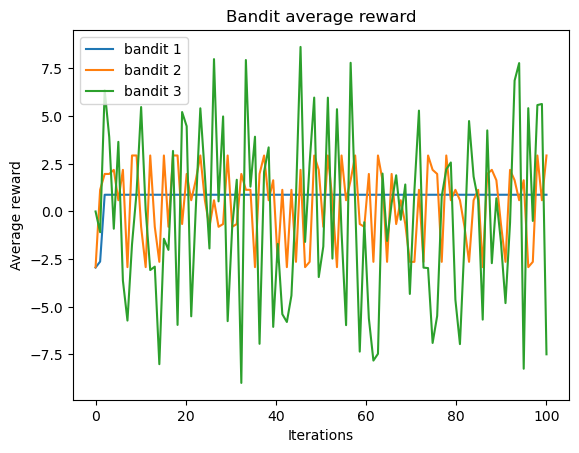

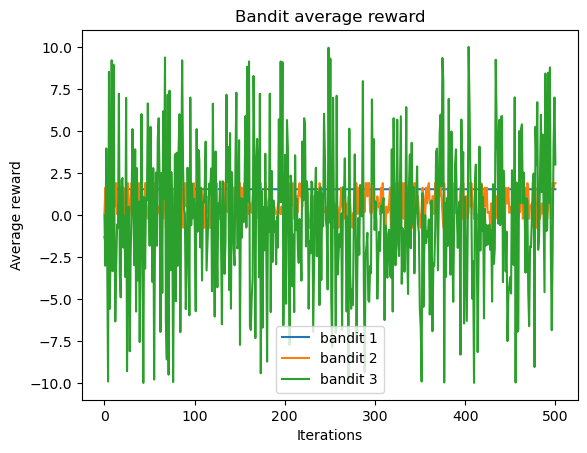

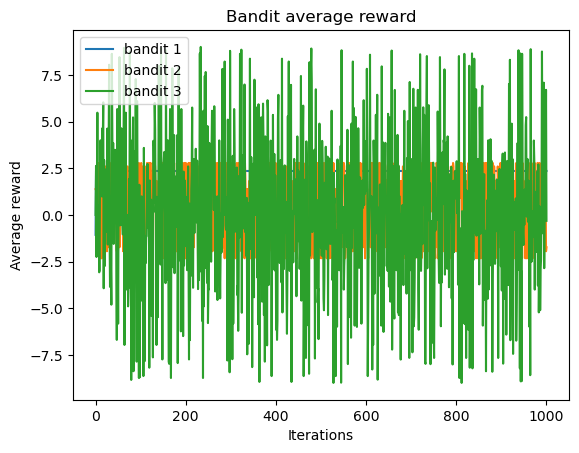

In [86]:
import numpy as np
# b1andit = Bandit(episodes=1000,arms_values=arms_values)  
import matplotlib.pyplot as plt
# x axis data

n_episodes = 100
x = np.linspace(0, n_episodes, n_episodes)

# plot definition


# y axis data definition and graph definition 
def plot_bandits(bandits=[Bandit(10)]):
    for i,b in enumerate(bandits):
        y = np.array(b.run())
        ax.plot(x, y,  label=f'bandit {i+1}')

#example: plot with 3 bandits
#remove the coment for the case you want to observe
for n_episodes in [100,500,1000]:
    fig, ax = plt.subplots()
    plt.title("Bandit average reward")
    plt.xlabel("Iterations")
    plt.ylabel("Average reward")
    x = np.linspace(0, n_episodes, n_episodes)
    plot_bandits([Bandit(10,episodes=n_episodes),Bandit2(10,episodes=n_episodes),Bandit3(10,episodes=n_episodes)])

    ax.legend()
    plt.show()

Como se puede observar en la comparación, el bandido greedy es el que menos explora y pasa directamente a explotar lo que encuentra como la mejor opción tras unas pocas iteraciones. Por otro lado, el bandido $\epsilon$-greedy encuentra un mejor equilibrio ya que como podemos observar explora mucho mejor las opciones y obtiene mejores recompensas aunque también encuentra perdidas en la recompensa promedio. Es así como finalmente, el bandido con las recompensas no estacionarias es el que tiene el comportamiento más interesante en las gráficas, ya que se puede observar que tiene una gran capacidad de adaptación a la hora que va cambiando la recompensa, de esta forma, es el que presenta los picos más altos y los valles más bajos. 

A continuación una comparación de los 2 bandidos con recompensas estacionarias. 

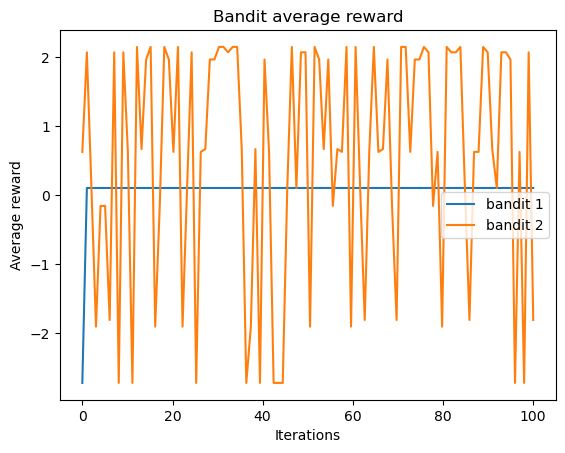

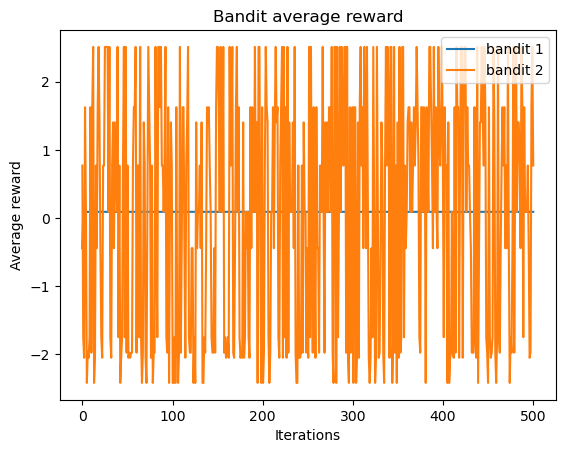

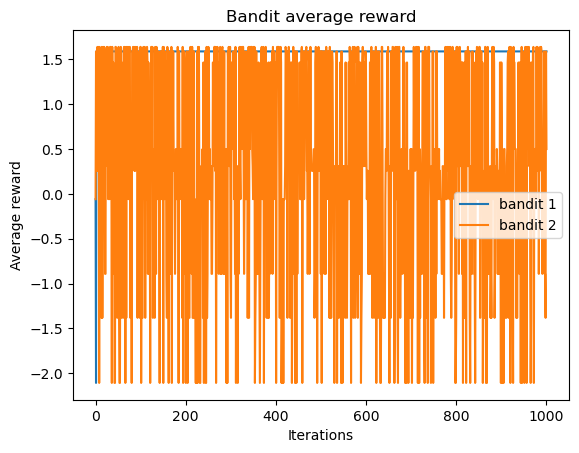

In [94]:
import numpy as np
import matplotlib.pyplot as plt

def plot_bandits(bandits=[Bandit(10)]):
    for i,b in enumerate(bandits):
        y = np.array(b.run())
        ax.plot(x, y,  label=f'bandit {i+1}')

#example: plot with 3 bandits
#remove the coment for the case you want to observe
for n_episodes in [100,500,1000]:
    fig, ax = plt.subplots()
    plt.title("Bandit average reward")
    plt.xlabel("Iterations")
    plt.ylabel("Average reward")
    x = np.linspace(0, n_episodes, n_episodes)
    
    arms_values = [random.uniform(-3,3) for _ in range(10)]
    plot_bandits([Bandit(10,episodes=n_episodes,arms_values=arms_values),Bandit2(10,episodes=n_episodes,arms_values=arms_values)])

    ax.legend()
    plt.show()

Aquí se puede apreciar lo dicho anteriormente, el bandido 2 tiene una mejor exploración y de esta forma en el caso general encuentra recompensas mejores y a la misma vez peores que el bandido greedy. 